In [7]:
##import assembly results

assembly_paths = {}

tsv_file = "L1.hpv_chains.tsv"   

with open(tsv_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        # 以第一个 tab 分开 contig 和后面的路径
        parts = line.split("\t", 1)
        if len(parts) < 2:
            continue

        contig = parts[0].strip()
        path = parts[1].strip()

        # 直接存成 string（不是 tuple）
        assembly_paths[contig] = path


def extract_minimal_hpv_chain(path):
    """
    给定一条 assembly path（string），只保留：
    - HPV 片段
    - HPV 片段前一段 host
    - HPV 片段后一段 host
    """

    segments = [p.strip() for p in path.split("->")]
    # 找出哪些 segments 是 HPV
    hpv_idxs = [i for i,s in enumerate(segments) if "HPV" in s.upper()]

    if not hpv_idxs:
        return None

    first_hpv = min(hpv_idxs)
    last_hpv  = max(hpv_idxs)

    # host before = first_hpv - 1（如果存在）
    before_idx = first_hpv - 1 if first_hpv - 1 >= 0 else None

    # host after = last_hpv + 1（如果存在）
    after_idx = last_hpv + 1 if last_hpv + 1 < len(segments) else None

    selected = []

    if before_idx is not None:
        selected.append(segments[before_idx])

    # all HPV segments
    selected.extend(segments[first_hpv:last_hpv+1])

    if after_idx is not None:
        selected.append(segments[after_idx])

    return " -> ".join(selected)


# ------------------------------------
# 处理所有 assembly paths
# ------------------------------------

assembly_paths_minimized = {}

for contig, path in assembly_paths.items():
    new_path = extract_minimal_hpv_chain(path)
    if new_path:   
        assembly_paths_minimized[contig] = new_path

import pprint
pprint.pprint(assembly_paths_minimized)



{'ctg10': 'chr3:63220252-66334636(+) -> HPV:1-3375(-) -> HPV:5305-7906(-) -> '
          'chr3:66468873-72044966(+)',
 'ctg109': 'chr7:154164872-157309408(+) -> HPV:1399-2486(-) -> '
           'chr7:157443648-157731579(+)',
 'ctg112': 'chr11:131776425-131789342(+) -> HPV:1-3372(-) -> HPV:5305-7906(-) '
           '-> chr11:131923580-134934670(+)',
 'ctg1334': 'chr1:161271140-161450549(-) -> HPV:5305-7906(+) -> HPV:1-3367(+) '
            '-> chr1:161136051-161136903(-)',
 'ctg16': 'chr6:93515806-94199118(-) -> HPV:5305-7906(+) -> HPV:1-3373(+) -> '
          'chr6:90674657-93381572(-) -> chr6:90673414-90674098(-) -> '
          'chr6:89227897-90670045(-) -> chr6:83339099-89226955(-) -> '
          'chr6:82914411-83332896(-) -> chr6:80920617-82914400(-) -> '
          'chr6:80917720-80919908(-) -> chr6:79618582-80917540(-) -> '
          'HPV:5305-7906(+) -> HPV:2-3372(+) -> chr6:77725710-79478297(-)',
 'ctg19': 'chr7:7472168-8531584(+) -> HPV:1-3372(-) -> HPV:5304-7906(-) -> '
       

In [8]:
import csv
import re
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict

import pandas as pd

# ========= 数据结构 =========

@dataclass
class Segment:
    seq: str           # 'HPV', 'chr3', 'chr17', 'LIT' 等
    start: int         # 1-based inclusive
    end: int           # 1-based inclusive
    strand: str        # '+' or '-'

    def length(self) -> int:
        return max(0, self.end - self.start + 1)


@dataclass
class ContigPath:
    name: str
    segments: List[Segment]


@dataclass
class TruthEvent:
    event_id: str
    chrom: str
    host_pos: int
    pattern_str: str
    segments: List[Segment] = field(default_factory=list)


# ========= 解析函数 =========

# 单个 segment 的正则: HPV:...(...), chr17:...(...), 等
SEGMENT_RE = re.compile(r'(?P<name>[^:]+):(?P<coords>[^()]+)\((?P<strand>[+-])\)')

# 在 truth hpv_path 里提取 token:
#   - LIT:5
#   - 或任意 "...(...)" 
TOKEN_RE = re.compile(r'LIT:\d+|[^+]+\([+-]\)')

def normalize_contig_segments(seglist: List[Segment]) -> List[Segment]:
    """
    如果第一个出现的 host chr 段是负链（strand == '-'），
    就把整个 contig 反转（segments 顺序反转，并翻转 strand）。
    坐标 start/end 保持不变，因为是基因组坐标。
    """
    host_idx = None
    for i, seg in enumerate(seglist):
        if seg.seq not in ("HPV", "LIT"):
            host_idx = i
            break

    if host_idx is None:
        # 没有 chr 段（纯 HPV 或 LIT），不需要反转
        return seglist

    host = seglist[host_idx]
    if host.strand != "-":
        # 第一个 host 已经是 + 链，保持
        return seglist

    # 需要反转：顺序反转 + strand 翻转
    new_list: List[Segment] = []
    for seg in reversed(seglist):
        if seg.strand == "+":
            new_strand = "-"
        elif seg.strand == "-":
            new_strand = "+"
        else:
            new_strand = seg.strand
        new_list.append(
            Segment(seq=seg.seq, start=seg.start, end=seg.end, strand=new_strand)
        )
    return new_list

def parse_segment_token(token: str) -> List[Segment]:
    """
    解析单个 token，比如:
      'HPV:2599-4572(+)' 
      'HPV:1-4101,3572-7906(-)'
      'chr17:36094082-36099602(+)' 
      'LIT:5'
    返回 Segment 列表（因为 HPV 多段会拆成多个 Segment）
    """
    token = token.strip()

    # LIT:5 这种占位符
    if token.startswith("LIT:"):
        k = int(token.split(":")[1])
        # 这里假设单位是 kb：LIT:5 -> 5000bp
        length = k * 1000
        return [Segment(seq="LIT", start=1, end=length, strand='+')]

    m = SEGMENT_RE.match(token)
    if not m:
        raise ValueError(f"Cannot parse segment token: {token}")

    name = m.group("name")
    coords_str = m.group("coords")
    strand = m.group("strand")

    segs: List[Segment] = []
    for part in coords_str.split(","):
        part = part.strip()
        if not part:
            continue
        s_str, e_str = part.split("-")
        s = int(s_str)
        e = int(e_str)
        if e < s:
            # 保证 start <= end（坐标方向统一，用 strand 单独表示）
            s, e = e, s
        segs.append(Segment(seq=name, start=s, end=e, strand=strand))
    return segs


def parse_truth_pattern(pattern: str) -> List[Segment]:
    """
    从 truth 的 hpv_path 字段解析出所有 Segment.
    通过 TOKEN_RE 抓 token，避免被 '(+)' 里的 '+' 搞乱。
    """
    segments: List[Segment] = []
    for tok in TOKEN_RE.findall(pattern):
        segments.extend(parse_segment_token(tok))
    return segments


def parse_assembly_path(path: str) -> List[Segment]:
    """
    从 assembly 的 path 字符串解析 Segment:
      'chr3:157752279-158021385(-) -> HPV:3854-4572(-)'
      'HPV:1-4572(+) -> HPV:1-1321(-) -> HPV:6164-7906(-) -> HPV:6090-7348(+)'
    用 '->' 分隔，再逐个 token 解析。
    """
    segments: List[Segment] = []
    for tok in path.split("->"):
        tok = tok.strip()
        if not tok:
            continue
        segments.extend(parse_segment_token(tok))
    return segments


# ========= I/O =========

def load_truth_events(truth_tsv: str) -> Dict[str, TruthEvent]:
    """
    读取 truth 文件 (比如 100_fakeEF.events.tsv).
    需要这些列:
      event_id, chrom, host_pos, hpv_path
    其它列会忽略。
    """
    events: Dict[str, TruthEvent] = {}

    with open(truth_tsv, newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        required_cols = {"event_id", "chrom", "host_pos", "hpv_path"}
        missing = required_cols - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f"Truth file missing columns: {missing}")

        for row in reader:
            eid = row["event_id"]
            chrom = row["chrom"]
            host_pos = int(row["host_pos"])
            pattern_str = row["hpv_path"]
            segs = parse_truth_pattern(pattern_str)

            events[eid] = TruthEvent(
                event_id=eid,
                chrom=chrom,
                host_pos=host_pos,
                pattern_str=pattern_str,
                segments=segs
            )

    return events


def load_contig_paths_from_dict(path_dict: Dict[str, str]) -> Dict[str, ContigPath]:
    """
    从 Python dict 读取 assembly path:
      key: contig 名 (ctg16...)
      value: path 字符串

    并对每条 contig 做 normalize_contig_segments：
      - 如果第一个 host 是负链，就反转整个 contig。
    """
    contigs: Dict[str, ContigPath] = {}
    for name, path_str in path_dict.items():
        segs = parse_assembly_path(path_str)
        segs = normalize_contig_segments(segs)
        contigs[name] = ContigPath(name=name, segments=segs)
    return contigs


# ========= 工具函数 =========

def find_host_anchor(seglist: List[Segment]) -> Tuple[Optional[Segment], Optional[str]]:
    """
    在已经 normalize 过的 segments 里，
    找到第一个 HPV 段附近的 host 段（seq 不是 HPV/LIT）。

    返回:
      host_seg: Segment 或 None
      side: "left" 或 "right"，表示 HPV 在 host 的哪一侧

    规则：
      1. 找第一个 HPV
      2. 优先用左边的 host（HPV 左边一个 segment 是 chr）
         - 这种情况 HPV 紧接在 host 的右边 → anchor 是 host 的 right 端 (end)
      3. 若左边没有 host，再用右边的 host
         - 这种情况 HPV 在 host 左边 → anchor 是 host 的 left 端 (start)
    """
    first_hpv_idx = None
    for i, seg in enumerate(seglist):
        if seg.seq == "HPV":
            first_hpv_idx = i
            break

    if first_hpv_idx is None:
        return None, None

    i = first_hpv_idx

    # 先看左边是否是 host
    if i - 1 >= 0:
        left = seglist[i - 1]
        if left.seq not in ("HPV", "LIT"):
            # host -> HPV
            return left, "right"   # junction 在 host.right 端

    # 再看右边
    if i + 1 < len(seglist):
        right = seglist[i + 1]
        if right.seq not in ("HPV", "LIT"):
            # HPV -> host
            return right, "left"   # junction 在 host.left 端

    return None, None


def assign_contigs_to_events(
    contigs: Dict[str, ContigPath],
    events: Dict[str, TruthEvent],
    max_dist: int = 1_000_000
) -> Dict[str, List[ContigPath]]:
    """
    根据 'HPV 邻接的 host chr 段的 junction 坐标' 把 contigs 分配到最近的 truth event。

    anchor_pos:
      - 如果 HPV 在 host 右边（host -> HPV），取 host.end
      - 如果 HPV 在 host 左边（HPV -> host），取 host.start
    """
    by_event: Dict[str, List[ContigPath]] = defaultdict(list)

    # 按 chrom 索引 truth events
    events_by_chrom: Dict[str, List[TruthEvent]] = defaultdict(list)
    for ev in events.values():
        events_by_chrom[ev.chrom].append(ev)

    for ctg in contigs.values():
        host_seg, side = find_host_anchor(ctg.segments)
        if host_seg is None or side is None:
            continue

        chrom = host_seg.seq
        if side == "right":
            anchor_pos = host_seg.end
        else:  # "left"
            anchor_pos = host_seg.start

        candidates = events_by_chrom.get(chrom, [])
        if not candidates:
            continue

        best_ev = None
        best_dist = None
        for ev in candidates:
            d = abs(ev.host_pos - anchor_pos)
            if best_dist is None or d < best_dist:
                best_dist = d
                best_ev = ev

        if best_ev is not None and best_dist is not None and best_dist <= max_dist:
            by_event[best_ev.event_id].append(ctg)

    return by_event



def merge_intervals(intervals: List[Tuple[int, int]]) -> int:
    """
    intervals: 若干 [start, end] 闭区间（1-based, start <= end）.
    返回这些区间 union 的总长度（碱基数）。
    """
    if not intervals:
        return 0

    intervals.sort()
    merged_len = 0
    cur_s, cur_e = intervals[0]

    for s, e in intervals[1:]:
        if s <= cur_e + 1:
            cur_e = max(cur_e, e)
        else:
            merged_len += cur_e - cur_s + 1
            cur_s, cur_e = s, e

    merged_len += cur_e - cur_s + 1
    return merged_len


def compute_event_accuracy(
    event: TruthEvent,
    contigs_for_event: List[ContigPath]
) -> Tuple[int, int, float]:
    """
    对一个 truth event：
      truth_len  = 该 event 所有 segments 的碱基数总和（含 HPV + chr + LIT）
      covered_bp = 被 assembly 覆盖的 truth 碱基数（按 seq 匹配 + union overlap）
      accuracy   = covered_bp / truth_len
    """
    truth_len = sum(seg.length() for seg in event.segments)
    if truth_len == 0:
        return 0, 0, 0.0

    covered_total = 0

    for tseg in event.segments:
        intervals: List[Tuple[int, int]] = []

        for ctg in contigs_for_event:
            for a in ctg.segments:
                if a.seq != tseg.seq:
                    continue
                # strand 不作为过滤条件，只是记录；这里只考虑坐标 overlap
                s = max(a.start, tseg.start)
                e = min(a.end, tseg.end)
                if e >= s:
                    intervals.append((s, e))

        covered_total += merge_intervals(intervals)

    accuracy = covered_total / truth_len if truth_len > 0 else 0.0
    return truth_len, covered_total, accuracy


def compute_event_accuracy_df(
    truth_tsv: str,
    assembly_paths_dict: Dict[str, str],
    max_dist: int = 1_000_000
) -> pd.DataFrame:
    """
    主函数：给 truth tsv 路径 和 assembly 的 dict，返回一个 DataFrame。
    """
    # 读 truth
    events = load_truth_events(truth_tsv)
    # 读 assembly
    contigs = load_contig_paths_from_dict(assembly_paths_dict)
    # contig 分配到 event
    contigs_by_event = assign_contigs_to_events(contigs, events, max_dist=max_dist)

    records = []
    for eid, ev in events.items():
        assigned = contigs_by_event.get(eid, [])
        truth_len, covered_len, acc = compute_event_accuracy(ev, assigned)
        records.append({
            "event_id": eid,
            "chrom": ev.chrom,
            "host_pos": ev.host_pos,
            "truth_pattern": ev.pattern_str,
            "truth_length_bp": truth_len,
            "covered_bp": covered_len,
            "accuracy": acc,
            "n_contigs": len(assigned),
            "assigned_contigs": ",".join(c.name for c in assigned) if assigned else ""
        })

    df = pd.DataFrame.from_records(records)
    return df


In [9]:
truth_file = "100_1218planAB.events.tsv"   

df_acc = compute_event_accuracy_df(truth_file, assembly_paths_minimized, max_dist=1_000_000)
df_acc

,event_id,chrom,host_pos,truth_pattern,truth_length_bp,covered_bp,accuracy,n_contigs,assigned_contigs
0,E1_RAND61_A,chr1,236888126,HPV:1706-6292(+),4587,0,0.000000,0,
1,E2_Dup_B,chr1,234783386,"HPV:5305-7906,1-3372(-)",5974,0,0.000000,0,
2,E3_RAND55_A,chr1,228366844,HPV:1706-6292(+),4587,0,0.000000,0,
3,E4_RAND58_B,chr1,197773456,"HPV:5305-7906,1-3372(-)",5974,0,0.000000,0,
4,E5_RAND64_A,chr1,182939799,HPV:1706-6292(+),4587,0,0.000000,0,
...,...,...,...,...,...,...,...,...,...
95,E96_LINE_B,chr18,22565190,"HPV:5305-7906,1-3372(-)",5974,5974,1.000000,1,ctg92
96,E97_RAND63_A,chr18,19014455,HPV:1706-6292(+),4587,684,0.149117,1,ctg2325
97,E98_RAND51_B,chr18,17566176,"HPV:5305-7906,1-3372(-)",5974,0,0.000000,0,
98,E99_RAND44_A,chr18,3751553,HPV:1706-6292(+),4587,0,0.000000,0,


In [10]:
df_acc_assigned = df_acc[df_acc["n_contigs"] > 0]
df_acc_assigned

,event_id,chrom,host_pos,truth_pattern,truth_length_bp,covered_bp,accuracy,n_contigs,assigned_contigs
5,E6_RAND91_B,chr1,161136902,"HPV:5305-7906,1-3372(-)",5974,5969,0.999163,1,ctg1334
7,E8_RAND85_B,chr1,147535266,"HPV:5305-7906,1-3372(-)",5974,5974,1.000000,1,ctg387
9,E10_RAND84_B,chr1,65688500,"HPV:5305-7906,1-3372(-)",5974,5961,0.997824,1,ctg5
17,E18_RAND59_B,chr2,167562060,"HPV:5305-7906,1-3372(-)",5974,5974,1.000000,1,ctg46
19,E20_RAND41_B,chr2,147610943,"HPV:5305-7906,1-3372(-)",5974,5955,0.996820,1,ctg33
23,E24_RAND62_B,chr2,7420804,"HPV:5305-7906,1-3372(-)",5974,5974,1.000000,1,ctg3
29,E30_EXTRA_B,chr3,93470597,"HPV:5305-7906,1-3372(-)",5974,687,0.114998,1,ctg2492
33,E34_RAND52_B,chr3,76730725,"HPV:5305-7906,1-3372(-)",5974,5974,1.000000,1,ctg4
35,E36_RAND25_B,chr3,66334635,"HPV:5305-7906,1-3372(-)",5974,5974,1.000000,1,ctg10
37,E38_RAND80_B,chr3,31906110,"HPV:5305-7906,1-3372(-)",5974,5974,1.000000,1,ctg51


In [11]:
def compute_insertion_bias_df(
    truth_tsv: str,
    assembly_paths_dict: Dict[str, str],
    max_dist: int = 1_000_000
) -> pd.DataFrame:
    """
    计算 assembly 的插入点 bias:
      bias_bp = assembly_junction_pos - truth_host_pos

    这里的 assembly_junction_pos 是：
      - host -> HPV: host.end
      - HPV -> host: host.start

    注意：contig 已经经过 normalize_contig_segments 处理。
    """
    events = load_truth_events(truth_tsv)
    contigs = load_contig_paths_from_dict(assembly_paths_dict)
    contigs_by_event = assign_contigs_to_events(contigs, events, max_dist=max_dist)

    records = []

    for eid, ev in events.items():
        assigned = contigs_by_event.get(eid, [])
        for ctg in assigned:
            host_seg, side = find_host_anchor(ctg.segments)
            if host_seg is None or side is None:
                continue

            if side == "right":
                asm_pos = host_seg.end
            else:  # "left"
                asm_pos = host_seg.start

            truth_pos = ev.host_pos
            bias = asm_pos - truth_pos

            records.append({
                "event_id": eid,
                "contig": ctg.name,
                "chrom": ev.chrom,
                "truth_host_pos": truth_pos,
                "assembly_junction_pos": asm_pos,
                "bias_bp": bias
            })

    return pd.DataFrame.from_records(records)


In [12]:
df_bias = compute_insertion_bias_df(truth_file, assembly_paths_minimized)
df_bias


,event_id,contig,chrom,truth_host_pos,assembly_junction_pos,bias_bp
0,E6_RAND91_B,ctg1334,chr1,161136902,161136903,1
1,E8_RAND85_B,ctg387,chr1,147535266,147535266,0
2,E10_RAND84_B,ctg5,chr1,65688500,65688501,1
3,E18_RAND59_B,ctg46,chr2,167562060,167562060,0
4,E20_RAND41_B,ctg33,chr2,147610943,147610943,0
5,E24_RAND62_B,ctg3,chr2,7420804,7420804,0
6,E30_EXTRA_B,ctg2492,chr3,93470597,93458691,-11906
7,E34_RAND52_B,ctg4,chr3,76730725,76730725,0
8,E36_RAND25_B,ctg10,chr3,66334635,66334636,1
9,E38_RAND80_B,ctg51,chr3,31906110,31906110,0


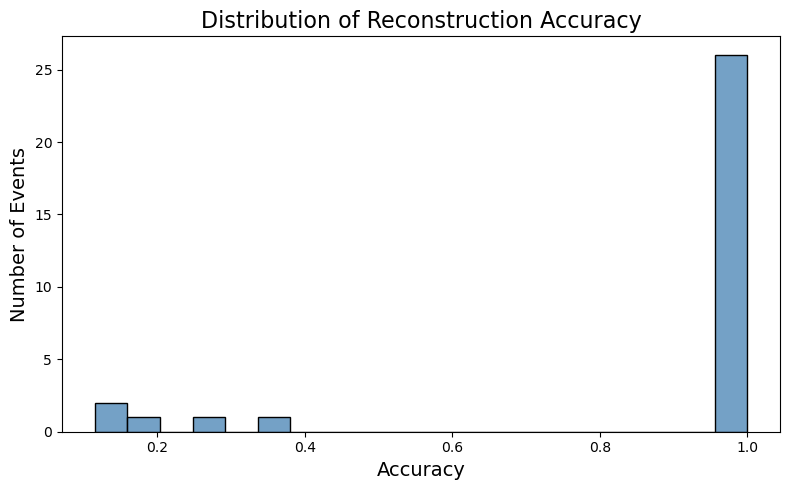

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(
    df_acc_assigned["accuracy"],
    bins=20, 
    kde=False, 
    color="steelblue"
)

plt.xlabel("Accuracy", fontsize=14)
plt.ylabel("Number of Events", fontsize=14)
plt.title("Distribution of Reconstruction Accuracy", fontsize=16)
plt.tight_layout()
plt.savefig("Accuracy_L1Whpv.pdf")
plt.show()


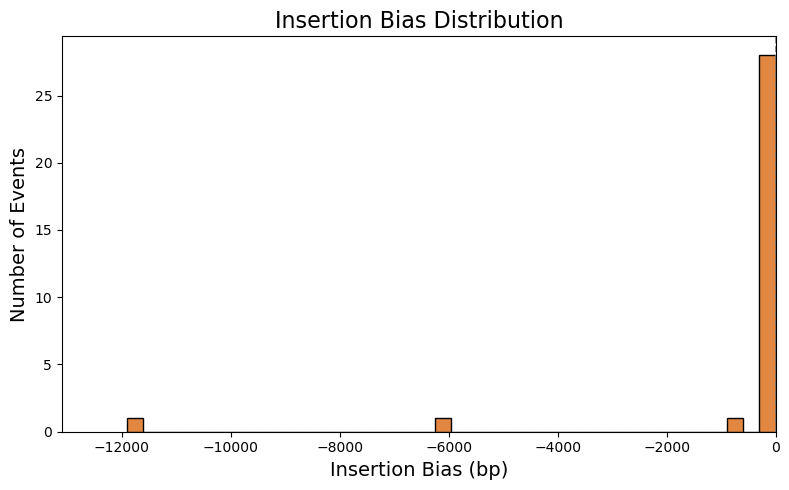

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_bias["bias_bp"],
    bins=40,
    kde=False,
    color="#d95f02"  
)

plt.axvline(0, color="gray", linestyle="--", linewidth=1.2)
plt.xlabel("Insertion Bias (bp)", fontsize=14)
plt.ylabel("Number of Events", fontsize=14)
plt.title("Insertion Bias Distribution", fontsize=16)

plt.xlim(df_bias["bias_bp"].min()*1.1, df_bias["bias_bp"].max()*1.1)

plt.tight_layout()
plt.savefig("Bias_L1Whpv.pdf")
plt.show()
